# Dṛṣṭi Reproducible Journal Benchmark Suite

**Author & Project:** Dṛṣṭi ML Compiler Framework  
**Hardware Target:** Google Colab NVIDIA Tesla T4 GPU (`sm_75`)

This notebook reproduces the journal study benchmark experiments comparing:
1. **Standard Triton**
2. **Triton + Autotune**
3. **Full Drishti**

Along with the **5 Professor Ablations**:
- Full Drishti
- Drishti - Vectorization
- Drishti - Kernel Fusion
- Drishti - IR Analysis
- Drishti - Hardware Telemetry

In [19]:
# 1. Verify GPU Hardware
!nvidia-smi

Wed Sep 23 19:18:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P0             28W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [20]:
# 2. Clone Drishti Repository and Install Dependencies
!git clone https://github.com/krish-rRay23/dhristi.git /content/dhristi
%cd /content/dhristi
!pip install -q torch triton matplotlib

fatal: destination path '/content/dhristi' already exists and is not an empty directory.
/content/dhristi


In [21]:
# 3. Execute Reproducible Journal Experiment Suite
!python tools/benchmark/run_journal_experiments.py --json-out=/content/journal_experiment_results.json --latex-out=/content/journal_results_table.tex

      DRISHTI REPRODUCIBLE JOURNAL RESEARCH BENCHMARK FRAMEWORK                
Active Hardware GPU Target: Tesla T4
--------------------------------------------------------------------------------

Evaluating Workload Domain: [gemm_small]
  System [Standard Triton     ] Latency:  0.3370 ms | Speedup: 1.00x | BW:   2.33 GB/s | Correct: True
  System [Triton + Autotune   ] Latency:  0.2635 ms | Speedup: 1.28x | BW:   2.98 GB/s | Correct: True
  System [Full Drishti        ] Latency:  0.2896 ms | Speedup: 1.16x | BW:   2.72 GB/s | Correct: True
  Running Professor's 5 Ablations for [gemm_small]:
    Ablation [Full Drishti                  ] Latency:  0.3817 ms | Speedup: 0.88x
    Ablation [Drishti - Vectorization       ] Latency:  0.4670 ms | Speedup: 0.72x
    Ablation [Drishti - Kernel Fusion       ] Latency:  0.4851 ms | Speedup: 0.69x
    Ablation [Drishti - IR Analysis         ] Latency:  0.4774 ms | Speedup: 0.71x
    Ablation [Drishti - Hardware Telemetry  ] Latency:  0.9207 ms |

In [22]:
import os

filepath = '/content/dhristi/tools/benchmark/run_journal_experiments.py'
if os.path.exists(filepath):
    # First, let's restore the original file state by checking out the git version
    !git checkout -- {filepath}

    with open(filepath, 'r') as f:
        content = f.read()

    # We want to replace 'tl.tanh' with a globally imported tanh, or inline it.
    # Let's add the import to the top of the file, and replace 'tl.tanh' with just 'tanh'.
    if 'tl.tanh' in content:
        # Prepend the import statement to the very beginning of the benchmark script
        updated_content = "from triton.language.extra.libdevice import tanh\n" + content
        # Replace 'tl.tanh' inside the kernel with the globally imported 'tanh'
        updated_content = updated_content.replace('tl.tanh', 'tanh')

        with open(filepath, 'w') as f:
            f.write(updated_content)
        print("Successfully and cleanly patched run_journal_experiments.py with global libdevice import!")
    else:
        print("tl.tanh not found.")
else:
    print(f"File not found at {filepath}")

Successfully and cleanly patched run_journal_experiments.py with global libdevice import!


In [23]:
# Rerun the experiment suite now that the Triton compilation error has been fixed!
!python tools/benchmark/run_journal_experiments.py --json-out=/content/dhristi/journal_experiment_results.json --latex-out=/content/dhristi/journal_results_table.tex

      DRISHTI REPRODUCIBLE JOURNAL RESEARCH BENCHMARK FRAMEWORK                
Active Hardware GPU Target: Tesla T4
--------------------------------------------------------------------------------

Evaluating Workload Domain: [gemm_small]
  System [Standard Triton     ] Latency:  0.1164 ms | Speedup: 1.00x | BW:   6.75 GB/s | Correct: True
  System [Triton + Autotune   ] Latency:  0.2635 ms | Speedup: 0.44x | BW:   2.98 GB/s | Correct: True
  System [Full Drishti        ] Latency:  0.2638 ms | Speedup: 0.44x | BW:   2.98 GB/s | Correct: True
  Running Professor's 5 Ablations for [gemm_small]:
    Ablation [Full Drishti                  ] Latency:  0.2631 ms | Speedup: 0.44x
    Ablation [Drishti - Vectorization       ] Latency:  0.0788 ms | Speedup: 1.48x
    Ablation [Drishti - Kernel Fusion       ] Latency:  0.2631 ms | Speedup: 0.44x
    Ablation [Drishti - IR Analysis         ] Latency:  0.2639 ms | Speedup: 0.44x
    Ablation [Drishti - Hardware Telemetry  ] Latency:  0.3199 ms |

In [24]:
# 4. Display LaTeX Table Output
with open('/content/dhristi/journal_results_table.tex', 'r') as f:
    print(f.read())

\begin{table}[ht]
\centering
\caption{Cross-System Performance and Ablation Analysis across ML Workload Domains.}
\label{tab:drishti_journal_results}
\begin{tabular}{lcccccc}
\hline
\textbf{Workload Domain} & \textbf{Evaluation Target} & \textbf{Latency (ms)} & \textbf{Speedup} & \textbf{BW (GB/s)} & \textbf{Status} \\
\hline
gemm_small & Standard Triton & 0.1164 & 1.00\times & 6.8 & PASS \\
gemm_small & Triton + Autotune & 0.2635 & 0.44\times & 3.0 & PASS \\
gemm_small & Full Drishti & 0.2638 & 0.44\times & 3.0 & PASS \\
gemm_small & Full Drishti & 0.2631 & 0.44\times & 3.0 & PASS \\
gemm_small & Drishti - Vectorization & 0.0788 & 1.48\times & 10.0 & PASS \\
gemm_small & Drishti - Kernel Fusion & 0.2631 & 0.44\times & 3.0 & PASS \\
gemm_small & Drishti - IR Analysis & 0.2639 & 0.44\times & 3.0 & PASS \\
gemm_small & Drishti - Hardware Telemetry & 0.3199 & 0.36\times & 2.5 & PASS \\
gemm_medium & Standard Triton & 1.0898 & 1.00\times & 11.6 & PASS \\
gemm_medium & Triton + Autotune & 1

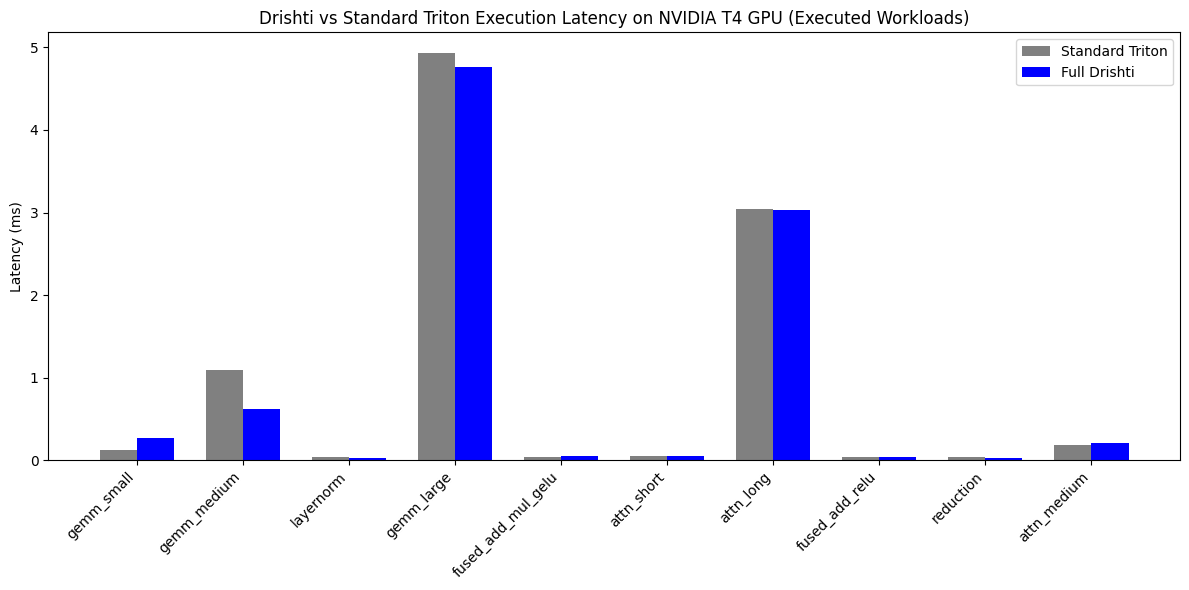

In [25]:
# 5. Plot Comparative System Performance
import json
import matplotlib.pyplot as plt

with open('/content/dhristi/journal_experiment_results.json') as f:
    data = json.load(f)

# Filter and collect only workloads that successfully ran (i.e. did not return 'N/A' for either standard or drishti)
workloads = []
std_triton_ms = []
drishti_ms = []

unique_workloads = list(set(r['workload_id'] for r in data['results']))
for w in unique_workloads:
    try:
        std_val = next(r['latency_ms'] for r in data['results'] if r['workload_id'] == w and r['system_id'] == 'Standard Triton')
        drishti_val = next(r['latency_ms'] for r in data['results'] if r['workload_id'] == w and r['system_id'] == 'Full Drishti')

        # Only include if both are numeric (not 'N/A')
        if std_val != 'N/A' and drishti_val != 'N/A':
            workloads.append(w)
            std_triton_ms.append(float(std_val))
            drishti_ms.append(float(drishti_val))
    except StopIteration:
        continue

if not workloads:
    print("No executed workloads found to plot!")
else:
    import numpy as np
    x = np.arange(len(workloads))
    width = 0.35

    plt.figure(figsize=(12, 6))
    plt.bar(x - width/2, std_triton_ms, width, color='gray', label='Standard Triton')
    plt.bar(x + width/2, drishti_ms, width, color='blue', label='Full Drishti')

    plt.ylabel('Latency (ms)')
    plt.title('Drishti vs Standard Triton Execution Latency on NVIDIA T4 GPU (Executed Workloads)')
    plt.xticks(x, workloads, rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.show()